# Kaggle information
- About this file (in kaggle) states: "The file is standardized, cleaned, and suitable for EDA, ML pipelines, and forecasting tasks."
- But I will still check 

In [26]:
# install.packages(c("tidyverse", "broom", "pROC", "randomForest", "caret"))

library(tidyverse) # Read csv (readr), manipulate data (dplyr), and plotting (ggplot2)
library(broom) # Tidy model outputs (Model specific, unlike tibble)
library(pROC) # ROC and AUC calculations (logistic regression ROC)
library(randomForest) # Fitting random Forest model
library(caret) # Train/Test split, confusion matrix, model evaluation

set.seed(9871)  # reproducible splits

In [6]:
# Load data set
hotel_raw = read.csv("C:\\Users\\dimar\\Desktop\\TLS\\UCF\\Semester1\\Statistics\\Final Project\\hotel_bookings_updated_2024.csv")

In [7]:
# Quick structure + first rows
glimpse(hotel_raw)
head(hotel_raw)

Rows: 119,390
Columns: 33
$ hotel                          <chr> "Resort Hotel - Chandigarh", "Resort Ho…
$ is_canceled                    <int> 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, …
$ lead_time                      <int> 342, 737, 7, 13, 14, 14, 0, 9, 85, 75, …
$ arrival_date_year              <int> 2024, 2024, 2024, 2024, 2024, 2024, 202…
$ arrival_date_month             <chr> "July", "April", "September", "August",…
$ arrival_date_week_number       <int> 30, 17, 37, 33, 37, 43, 1, 32, 34, 51, …
$ arrival_date_day_of_month      <int> 27, 28, 10, 14, 14, 23, 7, 8, 25, 18, 2…
$ stays_in_weekend_nights        <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ stays_in_week_nights           <int> 0, 0, 1, 1, 2, 2, 2, 2, 3, 3, 4, 4, 4, …
$ adults                         <int> 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ children                       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ babies                         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ meal        

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,⋯,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
1,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,⋯,NA,NA,0,Transient,0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh
2,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,⋯,NA,NA,0,Transient,0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai
3,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,⋯,NA,NA,0,Transient,75,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi
4,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,⋯,304,NA,0,Transient,75,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata
5,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,⋯,240,NA,0,Transient,98,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow
6,Resort Hotel - Delhi,0,14,2024,October,43,23,0,2,2,⋯,240,NA,0,Transient,98,0,1,Check-Out,2024-10-23 04:39:14.025915284,Delhi


In [8]:
# Column names for reference
names(hotel_raw)

[1] "hotel"                          "is_canceled"                   
 [3] "lead_time"                      "arrival_date_year"             
 [5] "arrival_date_month"             "arrival_date_week_number"      
 [7] "arrival_date_day_of_month"      "stays_in_weekend_nights"       
 [9] "stays_in_week_nights"           "adults"                        
[11] "children"                       "babies"                        
[13] "meal"                           "country"                       
[15] "market_segment"                 "distribution_channel"          
[17] "is_repeated_guest"              "previous_cancellations"        
[19] "previous_bookings_not_canceled" "reserved_room_type"            
[21] "assigned_room_type"             "booking_changes"               
[23] "deposit_type"                   "agent"                         
[25] "company"                        "days_in_waiting_list"          
[27] "customer_type"                  "adr"                           
[29] "required_car_parking_spaces"    "total_of_special_requests"     
[31] "reservation_status"             "reservation_status_date"       
[33] "city"

In [9]:
# NA counts per column
na_counts <- hotel_raw %>%
  summarise(across(everything(), ~ sum(is.na(.))))

# Display columns with NA counts greater than 0
na_counts %>%
  pivot_longer(cols = everything(),
               names_to = "Variable",
               values_to = "NA_Count") %>%
  filter(NA_Count > 0) %>%
  arrange(desc(NA_Count))

Variable,NA_Count
<chr>,<int>
company,112593
agent,16340
children,4


### **Initial thoughts**

Many columns contain zeros or empty-looking values that are not true missingness.
Examples include:

- stays_in_weekend_nights = 0, which is valid when guests do not stay over a weekend.

- is_canceled = 0, which correctly indicates the reservation was not canceled.

### **NA Counts**

Based on the NA summary, only three variables contain missing values: company, agent, and children.

- company and agent have extremely high missingness and are not necessary for the objectives of this analysis, so they will be excluded.

- children only has 4 missing rows; if this variable becomes relevant for modeling later, these rows can be dropped with negligible impact.

In [10]:
hotel_raw %>%
  select(is_canceled, lead_time) %>%
  arrange(desc(is_canceled)) %>%
  head()

,is_canceled,lead_time
,<int>,<int>
1,1,85
2,1,75
3,1,23
4,1,60
5,1,96
6,1,45


**Objective:**
- Objective is to predict when a reservation is canceled

**Required variables:**
- lead_time , is_canceled
- We can see higher numbers are more often to cancel in these 6. Potential strong predictor.

In [11]:
# Subset data to only relevant columns for normality test
leadtime_df <- hotel_raw %>%
  select(
    lead_time,
    is_canceled
  )

# Count rows before removing NA
n_before <- nrow(leadtime_df)

In [12]:
# Drop rows with NA in lead_time or is_canceled (if any)
leadtime_df <- leadtime_df %>%
  drop_na(lead_time, is_canceled)

# Count rows after removing NA
n_after <- nrow(leadtime_df)

# Calculate number of rows removed
rows_removed <- n_before - n_after

In [13]:
# Print row counts
cat("Rows before:", n_before, "\n",
    "Rows after :", n_after, "\n",
    "Rows removed:", rows_removed, "\n")

Rows before: 119390 
 Rows after : 119390 
 Rows removed: 0 


### **Normality Test Prep**
- Dataset was reduced to only the 'required' two variables. `lead_time` and `is_canceled`
- Verified no missing values (Expected given earlier test)

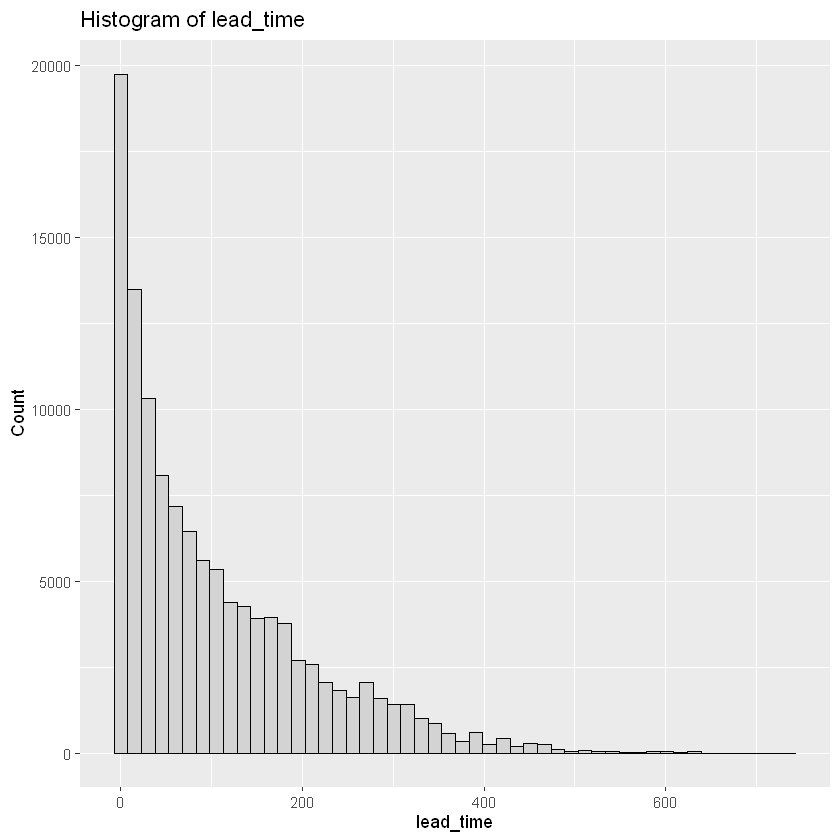

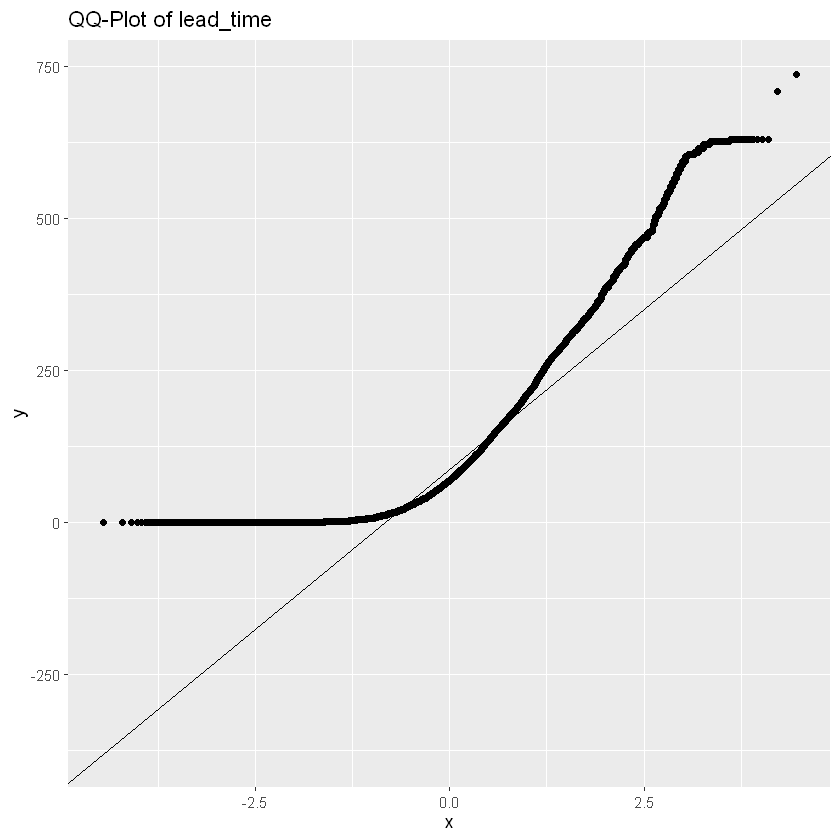

In [14]:
# Histogram of lead_time
leadtime_df %>%
  ggplot(aes(x = lead_time)) +
  geom_histogram(bins = 50, color = "black", fill = "lightgray") +
  labs(
    title = "Histogram of lead_time",
    x = "lead_time",
    y = "Count"
  )

# QQ-plot
leadtime_df %>%
  ggplot(aes(sample = lead_time)) +
  stat_qq() +
  stat_qq_line() +
  labs(
    title = "QQ-Plot of lead_time"
  )

In [15]:
# Shapiro-Wilk test (perform on a subsample because n is large)
lead_sample <- sample(
  leadtime_df$lead_time,
  size = min(5000, nrow(leadtime_df)),   # cap sample size at 5000
  replace = FALSE
)

shapiro_test <- shapiro.test(lead_sample)
shapiro_test


	Shapiro-Wilk normality test

data:  lead_sample
W = 0.85717, p-value < 2.2e-16


### **Normality Test Summary**

- lead_time shows a strong right-skew in both the histogram and QQ-plot.

- Shapiro–Wilk test indicates clear non-normality (p < 2.2e-16).

- Logistic regression does not require normality of predictors, and no transformation is needed.

- lead_time will be used in its original scale for modeling.

### **Key choice variables:**
- lead_time - Required, but also intuitively relevant. Longer time leading up to it, more time to cancel.
- adr (Average Daily Rate) - Reflects price of reservation; Economic factor
- total_of_special_requests - If more requests are met, they're more likely to commit over other places that didn't accomodate.
- previous_cancellations - A history of canceling already.
- booking changes - Moving around their booking, engaging with it. Potentially making special requests, or pushing back dates

In [16]:
# Create candidate dataframe for modeling
candidate_df <- hotel_raw %>%
  select(
    is_canceled,
    lead_time,
    adr,
    total_of_special_requests,
    previous_cancellations,
    booking_changes,
    market_segment,
    customer_type,
    deposit_type
  )

# Verify candidate dataframe
glimpse(candidate_df)

Rows: 119,390
Columns: 9
$ is_canceled               <int> 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,…
$ lead_time                 <int> 342, 737, 7, 13, 14, 14, 0, 9, 85, 75, 23, 3…
$ adr                       <dbl> 0.00, 0.00, 75.00, 75.00, 98.00, 98.00, 107.…
$ total_of_special_requests <int> 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 3, 1, 0,…
$ previous_cancellations    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ booking_changes           <int> 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,…
$ market_segment            <chr> "Direct", "Direct", "Direct", "Corporate", "…
$ customer_type             <chr> "Transient", "Transient", "Transient", "Tran…
$ deposit_type              <chr> "No Deposit", "No Deposit", "No Deposit", "N…


In [17]:
# Count rows before cleaning
n_before <- nrow(candidate_df)

# Drop rows with NA in any selected candidate variable
model_df <- candidate_df %>%
  drop_na(
    is_canceled,
    lead_time,
    adr,
    total_of_special_requests,
    previous_cancellations,
    booking_changes,
    market_segment,
    customer_type,
    deposit_type
  )

n_after <- nrow(model_df)
rows_removed <- n_before - n_after

cat("Rows before:", n_before, "\n",
    "Rows after :", n_after, "\n",
    "Rows removed:", rows_removed, "\n")

# Inspect cleaned modeling dataset
glimpse(model_df)

Rows before: 119390 
 Rows after : 119390 
 Rows removed: 0 


Rows: 119,390
Columns: 9
$ is_canceled               <int> 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,…
$ lead_time                 <int> 342, 737, 7, 13, 14, 14, 0, 9, 85, 75, 23, 3…
$ adr                       <dbl> 0.00, 0.00, 75.00, 75.00, 98.00, 98.00, 107.…
$ total_of_special_requests <int> 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 3, 1, 0,…
$ previous_cancellations    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ booking_changes           <int> 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,…
$ market_segment            <chr> "Direct", "Direct", "Direct", "Corporate", "…
$ customer_type             <chr> "Transient", "Transient", "Transient", "Tran…
$ deposit_type              <chr> "No Deposit", "No Deposit", "No Deposit", "N…


### **NA checking redundancy**
- The modeling step uses a different subset of variables, so I verify no missing values appear in this final set before splitting and fitting models.
- Just as a best practice, despite earlier global NA test.

In [18]:
# Convert outcome to factor for classification
model_df <- model_df %>%
  mutate(is_canceled = factor(is_canceled, levels = c(0, 1)))

In [19]:
# Create 70/30 split

# Generate training indices
train_index <- createDataPartition(
  y = model_df$is_canceled,
  p = 0.70,
  list = FALSE
)

# Split data into training and testing sets
train_df <- model_df[train_index, ]
test_df  <- model_df[-train_index, ]

# Display row counts
cat(" Training rows:", nrow(train_df), "\n",
    "Testing rows :", nrow(test_df), "\n")

# Verify 70/30 split
train_prop <- nrow(train_df) / nrow(model_df)
test_prop  <- nrow(test_df)  / nrow(model_df)

cat("\n", "Training proportion:", round(train_prop, 3), "\n",
    "Testing proportion :", round(test_prop, 3), "\n")

 Training rows: 83574 
 Testing rows : 35816 

 Training proportion: 0.7 
 Testing proportion : 0.3 


In [20]:
# Fit logistic regression using all candidate predictors
full_logit <- glm(
  is_canceled ~ lead_time +
    adr +
    total_of_special_requests +
    previous_cancellations +
    booking_changes +
    market_segment +
    customer_type +
    deposit_type,
  data = train_df,
  family = binomial(link = "logit")
)

# Tidy table with odds ratios
full_logit_tidy <- tidy(full_logit, exponentiate = TRUE, conf.int = TRUE)
full_logit_tidy

Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.484002e-01,1.946723e-01,-9.8002778,1.122765e-22,0.1003156,0.2155396
lead_time,1.004695e+00,1.009728e-04,46.3895352,0.000000e+00,1.0044964,1.0048941
adr,1.004043e+00,1.935215e-04,20.8498433,1.529224e-96,1.0036623,1.0044240
total_of_special_requests,4.759677e-01,1.332310e-02,-55.7231743,0.000000e+00,0.4636659,0.4885259
previous_cancellations,4.681982e+00,4.837903e-02,31.9088992,2.009518e-223,4.2614868,5.1513676
booking_changes,6.531349e-01,1.801178e-02,-23.6496033,1.191460e-123,0.6303143,0.6764292
market_segmentComplementary,5.825103e-01,2.426780e-01,-2.2268536,2.595706e-02,0.3621920,0.9395855
market_segmentCorporate,4.337419e-01,1.926884e-01,-4.3350069,1.457556e-05,0.2997679,0.6391344
market_segmentDirect,5.397438e-01,1.874008e-01,-3.2905988,9.997440e-04,0.3771399,0.7876664


### **Logistic Model Summary**

- Based on the logistic model summary, several predictors stand out as most influential:

    - lead_time — A significant positive predictor; reservations made further in advance show higher cancellation likelihood.

    - previous_cancellations — One of the strongest predictors; guests with prior cancellations are much more likely to cancel again.

    - total_of_special_requests — Strong negative effect; guests with more special requests are less likely to cancel.

    - deposit_type: Non-Refund, which shows extremely low cancellation rates and represents the strongest categorical effect.

    - These predictors have large effects and small p-values, making them the most important contributors to cancellation behavior. Other predictors are less influential or not significant and are not interpreted further.

**Note on error:**
    Predictors like `total_of_special_requests` and `deposit_typeNon Refund` show close to near deterministic patterns, which produces the warning.

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8296

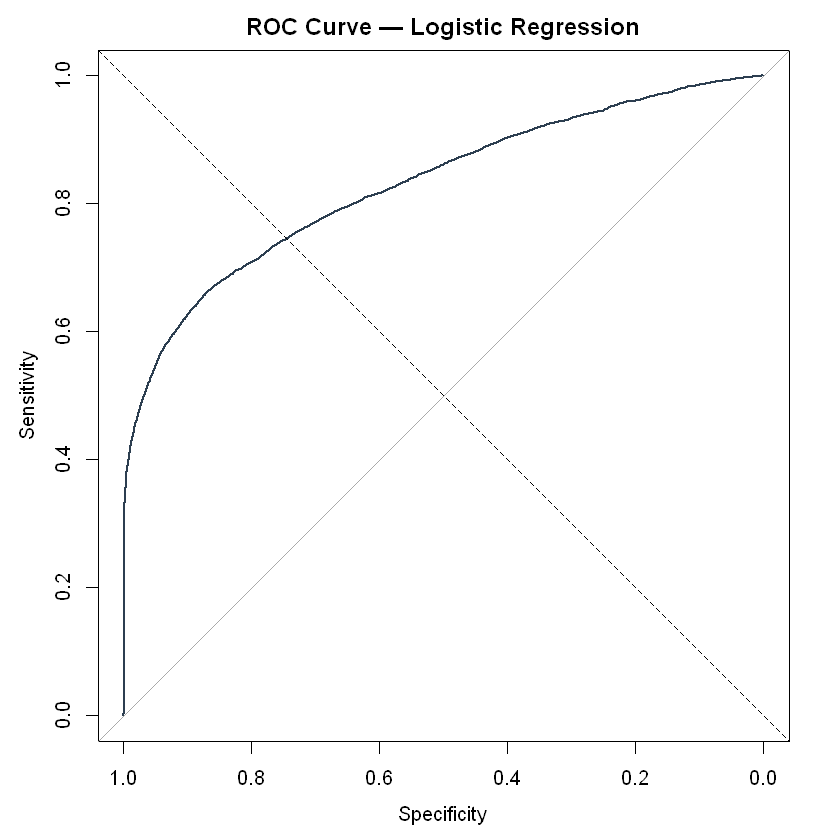

In [21]:
# Predicted probabilities on the test set
logit_prob <- predict(full_logit, newdata = test_df, type = "response")

# Convert test outcome to numeric (required for ROC)
test_outcome <- as.numeric(as.character(test_df$is_canceled))

# ROC curve object
logit_roc <- roc(test_outcome, logit_prob)

# AUC value
logit_auc <- auc(logit_roc)
logit_auc

# Plot ROC curve
plot(logit_roc,
     main = "ROC Curve — Logistic Regression",
     col = "#2C3E50",
     lwd = 2)
abline(a = 0, b = 1, lty = 2)


### **ROC curve**
- The ROC curve is much higher than the diagonal baseline
- AUC is 0.829: model is distinguishing between canceled and not canceled. 
- This model reliably separates high- and low-risk reservations

In [22]:
# Predicted probabilities from logistic model
logit_prob <- predict(full_logit, newdata = test_df, type = "response")

# Convert probabilities to class predictions (0.5 cutoff)
logit_pred_class <- ifelse(logit_prob >= 0.5, 1, 0)

# Convert to factor for caret
logit_pred_class <- factor(logit_pred_class, levels = c(0, 1))

# Confusion matrix
logit_CM <- confusionMatrix(
  data = logit_pred_class,
  reference = test_df$is_canceled,
  positive = "1"
)

# Display confusion matrix
logit_CM

Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 21322  5862
         1  1227  7405
                                          
               Accuracy : 0.8021          
                 95% CI : (0.7979, 0.8062)
    No Information Rate : 0.6296          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5428          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.5582          
            Specificity : 0.9456          
         Pos Pred Value : 0.8579          
         Neg Pred Value : 0.7844          
             Prevalence : 0.3704          
         Detection Rate : 0.2068          
   Detection Prevalence : 0.2410          
      Balanced Accuracy : 0.7519          
                                          
       'Positive' Class : 1               
                  

### **Confusion matrix**
- **Accuracy** = **0.802**, which is well above the no-information rate, showing the model performs meaningfully better than guessing.

- **Specificity** = **0.946** indicates the model is very strong at identifying bookings that do not cancel.

- **Sensitivity** = **0.558** shows the model captures over half of actual cancellations, but misses some.

- Overall, the model provides balanced performance with a **balanced accuracy** of **0.752**, which will serve as a baseline to compare against the Random Forest model

In [23]:
# Fit random forest using the same predictors as logistic regression
rf_model <- randomForest(
  is_canceled ~ lead_time +
    adr +
    total_of_special_requests +
    previous_cancellations +
    booking_changes +
    market_segment +
    customer_type +
    deposit_type,
  data = train_df,
  ntree = 500,
  mtry = 3
)

# Predicted classes on test set
rf_pred_class <- predict(rf_model, newdata = test_df, type = "class")

# Confusion matrix
rf_CM <- confusionMatrix(
  data = rf_pred_class,
  reference = test_df$is_canceled,
  positive = "1"
)

# Display confusion matrix
rf_CM

Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 21063  4989
         1  1486  8278
                                          
               Accuracy : 0.8192          
                 95% CI : (0.8152, 0.8232)
    No Information Rate : 0.6296          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5901          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.6240          
            Specificity : 0.9341          
         Pos Pred Value : 0.8478          
         Neg Pred Value : 0.8085          
             Prevalence : 0.3704          
         Detection Rate : 0.2311          
   Detection Prevalence : 0.2726          
      Balanced Accuracy : 0.7790          
                                          
       'Positive' Class : 1               
                  

,MeanDecreaseGini
lead_time,3555.4503
adr,1928.3524
total_of_special_requests,1941.2787
previous_cancellations,1733.2582
booking_changes,706.0822
market_segment,2094.9201
customer_type,823.2325
deposit_type,6764.5459


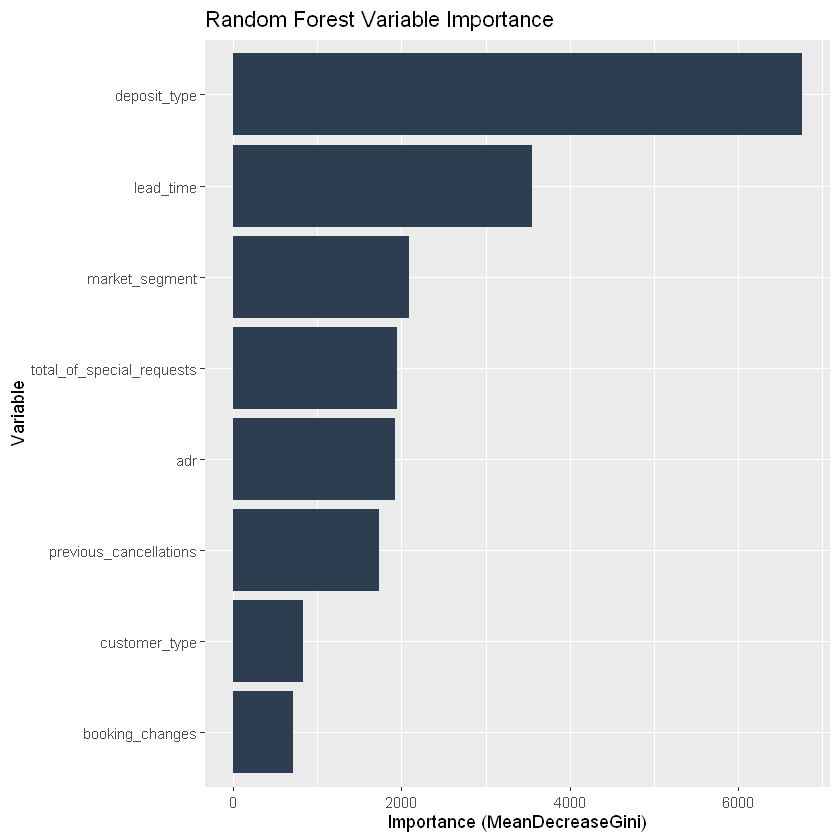

In [24]:
# Get variable importance
rf_importance <- importance(rf_model)
rf_importance

# Convert to a tidy data frame for plotting
rf_imp_df <- data.frame(
  Variable = rownames(rf_importance),
  Importance = rf_importance[, 1]
)

# Plot variable importance
rf_imp_plot <- rf_imp_df %>%
  ggplot(aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col(fill = "#2C3E50") +
  coord_flip() +
  labs(
    title = "Random Forest Variable Importance",
    x = "Variable",
    y = "Importance (MeanDecreaseGini)"
  )

# Display plot
rf_imp_plot

### **Random Forest Performance**

- Accuracy = 0.819, which is higher than the logistic model.

- Sensitivity = 0.626, meaning it captures more actual cancellations than the logistic model.

- Specificity = 0.932, slightly lower than logistic but still strong at identifying non-cancellations.

- Balanced accuracy = 0.779, also higher than the logistic model.

Overall, the Random Forest model shows better classification performance, especially in detecting canceled bookings.

In [25]:
# Extract confusion tables
logit_tab <- logit_CM$table
rf_tab    <- rf_CM$table

# Extract false positives and false negatives for Logistic Regression
logit_fp <- logit_tab["1", "0"]
logit_fn <- logit_tab["0", "1"]

# Extract false positives and false negatives for RF
rf_fp <- rf_tab["1", "0"]
rf_fn <- rf_tab["0", "1"]

# Compare in a small data frame
fp_fn_compare <- data.frame(
  Model           = c("Logistic", "Random Forest"),
  False_Positives = c(logit_fp, rf_fp),
  False_Negatives = c(logit_fn, rf_fn)
)

fp_fn_compare

Model,False_Positives,False_Negatives
<chr>,<int>,<int>
Logistic,1227,5862
Random Forest,1486,4989


### **Logistic Regression vs Random Forest**
- Random Forest catches more actual cancellations (fewer false negatives)

- Random Forest also predicts more cancellations overall (higher false positives)

### **Real world interpretation**

**False Positive (model predicts “canceled” but the guest does not cancel):**

- The hotel still has the booking.
- The room is occupied and paid for.
- No revenue is lost.
    
        At worst, the hotel may prepare for a cancellation that never happens. But there is no financial downside.

**False Negative (model predicts “not canceled” but the guest does cancel):**

- The room goes empty at the last minute.
- The hotel may be unable to resell it in time.
- This represents direct lost revenue.
        
        These are the mistakes the hotel most wants to reduce.